# **1. Perkenalan Dataset**


**Nama Dataset**: Diabetes Prediction Dataset  
**Sumber**: [Kaggle — Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)  
**Jumlah Data**: 100.000 baris, 9 kolom  
**Tipe Masalah**: Binary Classification (prediksi diabetes)

Dataset ini berisi informasi medis dan gaya hidup pasien yang digunakan untuk memprediksi apakah seseorang mengidap diabetes (`diabetes = 1`) atau tidak (`diabetes = 0`).

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `gender` | Kategorikal | Jenis kelamin (Female, Male, Other) |
| `age` | Numerik | Usia pasien (0.08 – 80 tahun) |
| `hypertension` | Biner | Riwayat hipertensi (1 = ya, 0 = tidak) |
| `heart_disease` | Biner | Riwayat penyakit jantung (1 = ya, 0 = tidak) |
| `smoking_history` | Kategorikal | Riwayat merokok (never, former, current, dll.) |
| `bmi` | Numerik | Body Mass Index |
| `HbA1c_level` | Numerik | Kadar HbA1c dalam darah |
| `blood_glucose_level` | Numerik | Kadar glukosa darah |
| `diabetes` | Biner | Label target (1 = diabetes, 0 = normal) |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
print('Library berhasil diimpor.')

Library berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
df = pd.read_csv('../dataset_raw/diabetes_prediction_dataset.csv')

print('Shape dataset:', df.shape)
print('\n5 baris pertama:')
df.head()

Shape dataset: (100000, 9)

5 baris pertama:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
print('Informasi Dataset:')
df.info()
print('\nStatistik Deskriptif:')
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Statistik Deskriptif:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

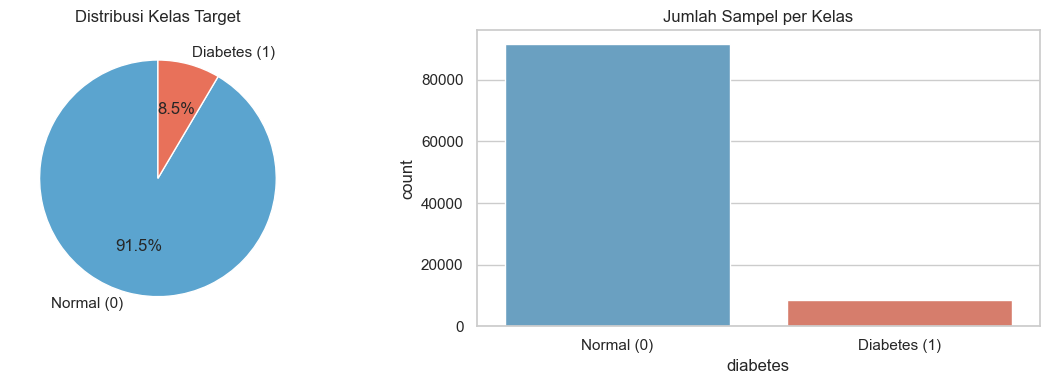

Distribusi kelas:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Rasio imbalance: 1:10


In [6]:
# 4.1 Distribusi Target (Class Imbalance Check)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['diabetes'].value_counts()
axes[0].pie(target_counts, labels=['Normal (0)', 'Diabetes (1)'],
            autopct='%1.1f%%', colors=['#5BA4CF', '#E8715A'], startangle=90)
axes[0].set_title('Distribusi Kelas Target')

sns.countplot(x='diabetes', data=df, palette=['#5BA4CF', '#E8715A'], ax=axes[1])
axes[1].set_title('Jumlah Sampel per Kelas')
axes[1].set_xticklabels(['Normal (0)', 'Diabetes (1)'])

plt.tight_layout()
plt.show()

print('Distribusi kelas:')
print(df['diabetes'].value_counts())
print(f'\nRasio imbalance: 1:{target_counts[0]//target_counts[1]}')

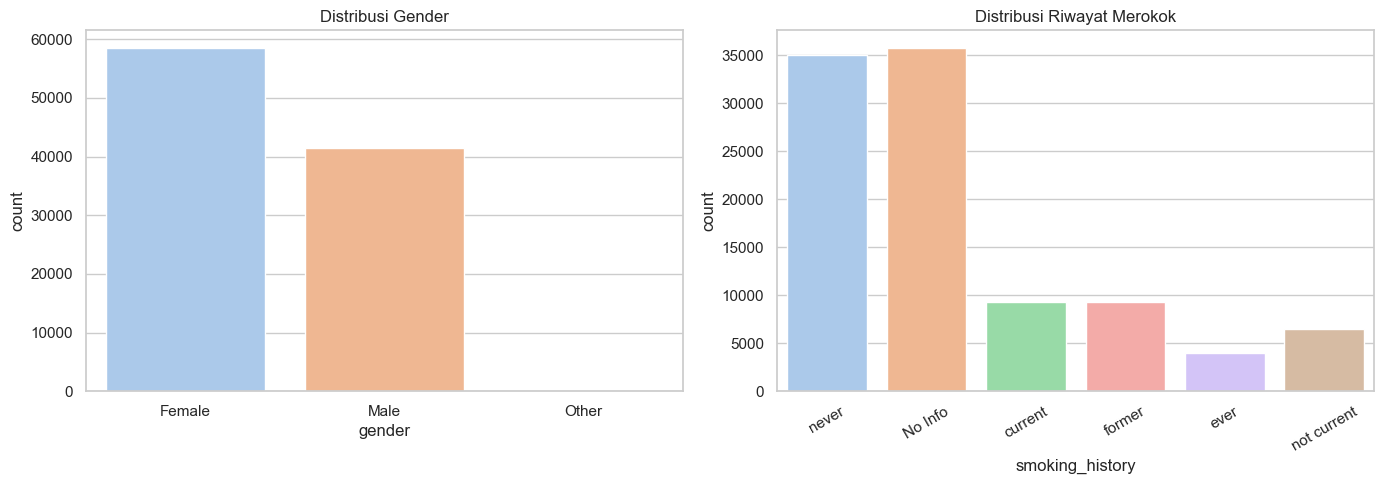

Gender value counts:
 gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Smoking history value counts:
 smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [7]:
# 4.2 Distribusi Fitur Kategorikal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='gender', data=df, palette='pastel', ax=axes[0])
axes[0].set_title('Distribusi Gender')

sns.countplot(x='smoking_history', data=df, palette='pastel', ax=axes[1])
axes[1].set_title('Distribusi Riwayat Merokok')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Gender value counts:\n', df['gender'].value_counts())
print('\nSmoking history value counts:\n', df['smoking_history'].value_counts())

In [8]:
# 4.3 Pemeriksaan Missing Values
missing = df.isnull().sum()
print('Missing values per kolom:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing values per kolom:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Total missing values: 0


In [9]:
# 4.4 Pemeriksaan Duplikat
dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup}')
print(f'Persentase duplikat  : {dup/len(df)*100:.2f}%')

Jumlah baris duplikat: 3854
Persentase duplikat  : 3.85%


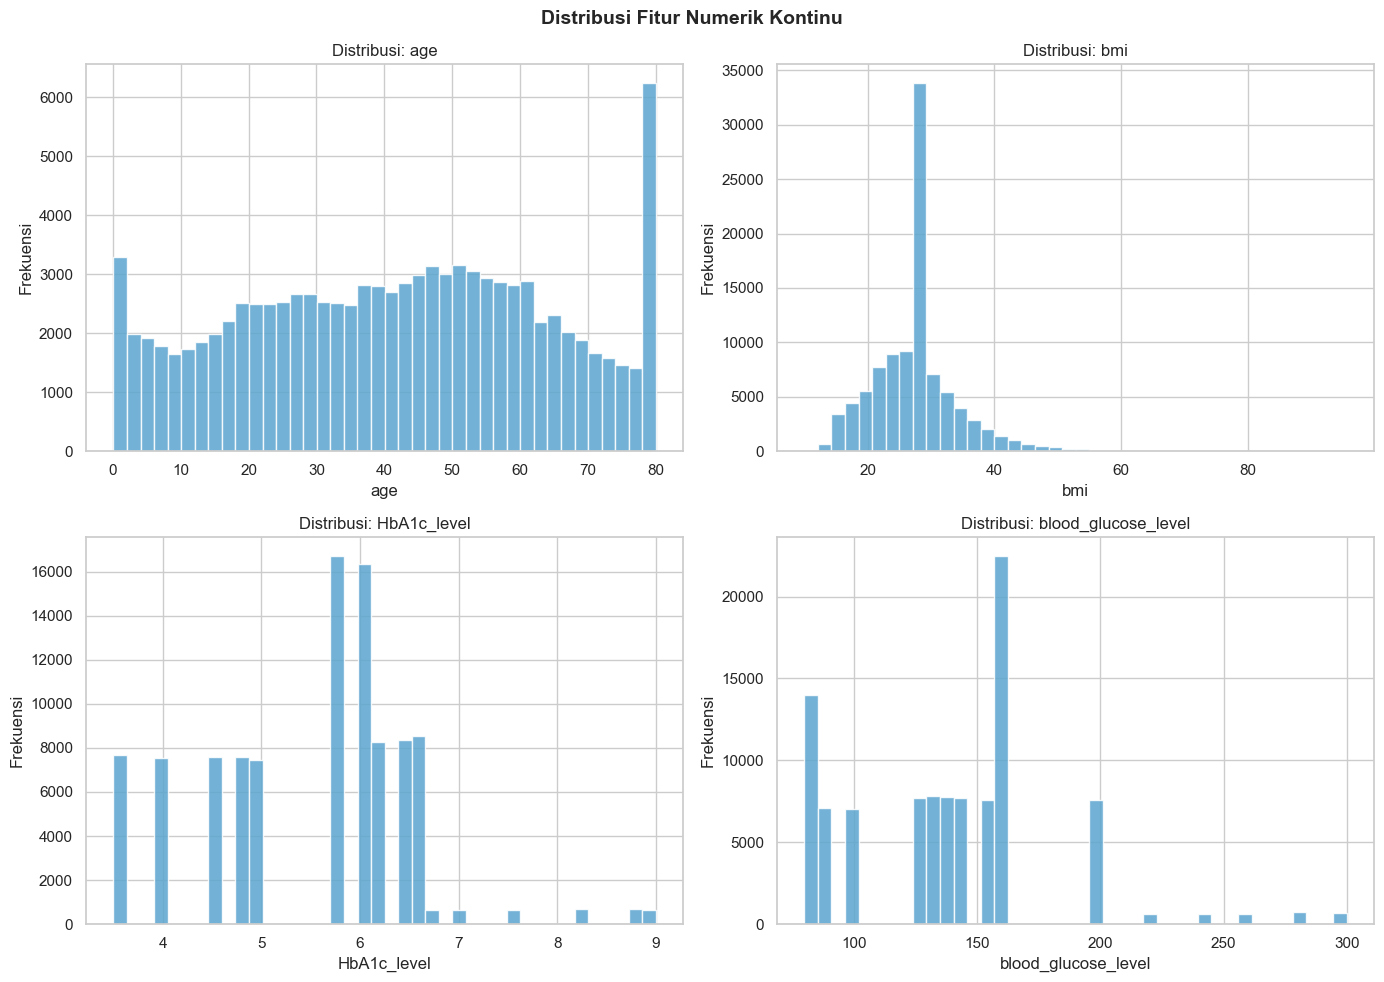

In [10]:
# 4.5 Distribusi Fitur Numerik Kontinu
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='#5BA4CF', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik Kontinu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

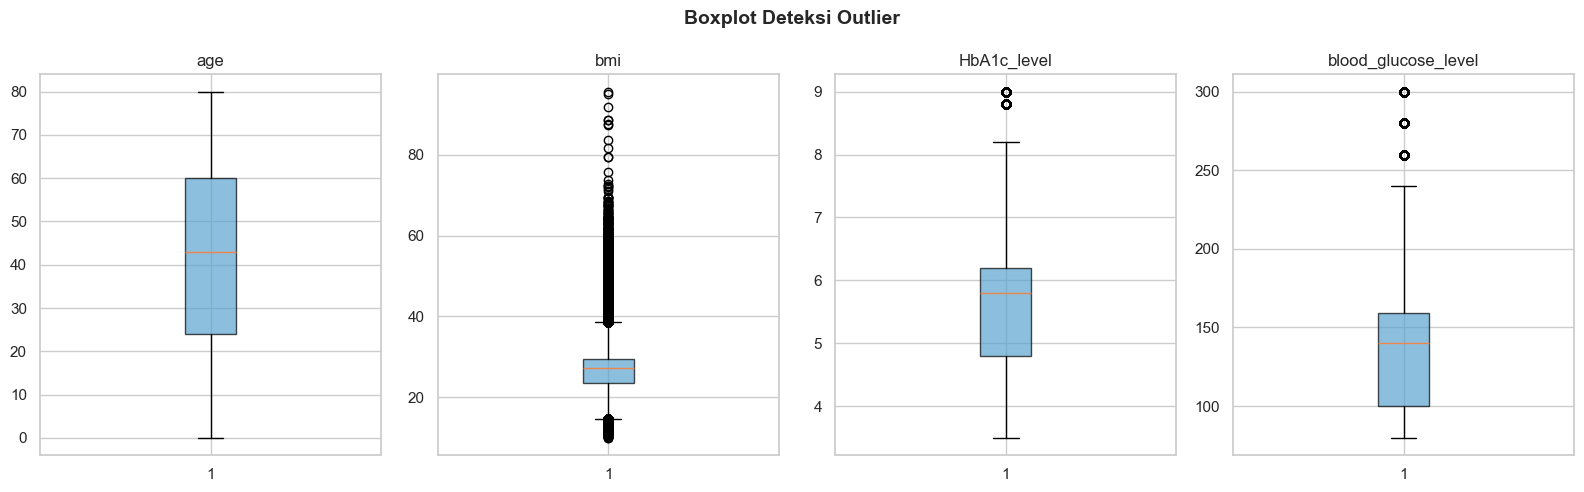

In [11]:
# 4.6 Boxplot Deteksi Outlier
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#5BA4CF', alpha=0.7))
    axes[i].set_title(col)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

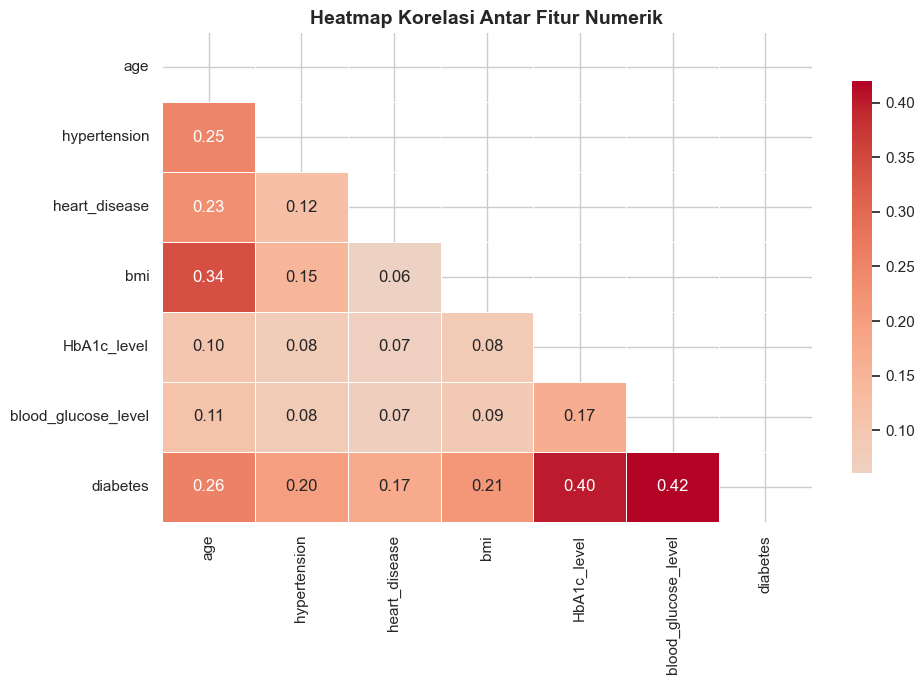

In [12]:
# 4.7 Heatmap Korelasi (fitur numerik)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 7))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# 5.1 Menangani Missing Values
print('Sebelum handling missing values:', df.shape)
missing = df.isnull().sum()
if missing.sum() == 0:
    print('Tidak ada missing values. Tidak ada tindakan diperlukan.')
else:
    num_cols_all = df.select_dtypes(include=[np.number]).columns
    df[num_cols_all] = df[num_cols_all].fillna(df[num_cols_all].median())
    cat_cols_all = df.select_dtypes(include=['object']).columns
    for col in cat_cols_all:
        df[col] = df[col].fillna(df[col].mode()[0])
    print('Missing values telah ditangani.')
print('Sesudah handling missing values:', df.shape)

Sebelum handling missing values: (100000, 9)
Tidak ada missing values. Tidak ada tindakan diperlukan.
Sesudah handling missing values: (100000, 9)


In [14]:
# 5.2 Menghapus Data Duplikat
print('Sebelum menghapus duplikat:', df.shape)
df = df.drop_duplicates().reset_index(drop=True)
print('Sesudah menghapus duplikat :', df.shape)

Sebelum menghapus duplikat: (100000, 9)
Sesudah menghapus duplikat : (96146, 9)


In [15]:
# 5.3 Menangani Outlier dengan Metode IQR
continuous_cols = ['bmi', 'HbA1c_level', 'blood_glucose_level']
print('Sebelum handling outlier:', df.shape)

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    removed = before - len(df)
    if removed > 0:
        print(f'  {col}: {removed} baris outlier dihapus (batas [{lower:.2f}, {upper:.2f}])')

df = df.reset_index(drop=True)
print('Sesudah handling outlier :', df.shape)

Sebelum handling outlier: (96146, 9)
  bmi: 5354 baris outlier dihapus (batas [13.71, 39.55])
  HbA1c_level: 1145 baris outlier dihapus (batas [2.70, 8.30])
  blood_glucose_level: 1452 baris outlier dihapus (batas [11.50, 247.50])
Sesudah handling outlier : (88195, 9)


In [16]:
# 5.4 Encoding Fitur Kategorikal
# Label Encoding: gender
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
print('gender → Label Encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding: smoking_history
print('\nSebelum OHE smoking_history:', df.shape)
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=False, dtype=int)
print('Sesudah OHE smoking_history :', df.shape)
print('Kolom baru:', df.columns.tolist())

gender → Label Encoding: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

Sebelum OHE smoking_history: (88195, 9)
Sesudah OHE smoking_history : (88195, 14)
Kolom baru: ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


In [17]:
# 5.5 Normalisasi Fitur Numerik Kontinu (MinMaxScaler)
scale_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
scale_cols = [c for c in scale_cols if c in df.columns]

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print('Normalisasi selesai. Rentang nilai setelah normalisasi:')
df[scale_cols].describe().loc[['min', 'max']]

Normalisasi selesai. Rentang nilai setelah normalisasi:


,age,bmi,HbA1c_level,blood_glucose_level
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


In [18]:
# 5.6 Simpan Dataset Hasil Preprocessing
import os
os.makedirs('diabetes_preprocessing', exist_ok=True)
output_path = 'diabetes_preprocessing/diabetes_preprocessed.csv'
df.to_csv(output_path, index=False)

print(f'Dataset tersimpan di: {output_path}')
print(f'Shape akhir         : {df.shape}')
print('\nPreview 5 baris pertama:')
df.head()

Dataset tersimpan di: diabetes_preprocessing/diabetes_preprocessed.csv
Shape akhir         : (88195, 14)

Preview 5 baris pertama:


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,1.000000,0,1,0.444272,0.659574,0.37500,0,0,0,0,0,1,0
1,0,0.674675,0,0,0.526703,0.659574,0.00000,0,1,0,0,0,0,0
2,1,0.349349,0,0,0.526703,0.468085,0.48750,0,0,0,0,0,1,0
3,0,0.449449,0,0,0.376935,0.319149,0.46875,0,0,1,0,0,0,0
4,1,0.949950,1,1,0.248839,0.276596,0.46875,0,0,1,0,0,0,0
